In [41]:
# Bài toán: Dự đoán Khả năng Nợ xấu (Credit Scoring)
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [42]:
df_training = pd.read_csv('F:/MachineLearning Tutorial/datasets/GiveMeSomeCredit/cs-training.csv')
# Xem dữ liệu
df_training.head()


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [43]:
df_training.info()
df_training.describe()

# Check missing values
df_training.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 12 columns):
 #   Column                                Non-Null Count   Dtype  
---  ------                                --------------   -----  
 0   Unnamed: 0                            150000 non-null  int64  
 1   SeriousDlqin2yrs                      150000 non-null  int64  
 2   RevolvingUtilizationOfUnsecuredLines  150000 non-null  float64
 3   age                                   150000 non-null  int64  
 4   NumberOfTime30-59DaysPastDueNotWorse  150000 non-null  int64  
 5   DebtRatio                             150000 non-null  float64
 6   MonthlyIncome                         120269 non-null  float64
 7   NumberOfOpenCreditLinesAndLoans       150000 non-null  int64  
 8   NumberOfTimes90DaysLate               150000 non-null  int64  
 9   NumberRealEstateLoansOrLines          150000 non-null  int64  
 10  NumberOfTime60-89DaysPastDueNotWorse  150000 non-null  int64  
 11  

Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

In [44]:
# Data Preprocessing
# df['MonthlyIncome'] 
# Xu li du lieu thieu va missing valueses
print(df_training['MonthlyIncome'].isnull().sum())
median_income = df_training['MonthlyIncome'].median()
df_training['MonthlyIncome'].fillna(median_income)


29731


0          9120.0
1          2600.0
2          3042.0
3          3300.0
4         63588.0
           ...   
149995     2100.0
149996     5584.0
149997     5400.0
149998     5716.0
149999     8158.0
Name: MonthlyIncome, Length: 150000, dtype: float64

In [45]:
# Kiểm tra dữ liệu có bất thường không va Xu li gia tri ngoai le
print(df_training[(df_training['age'] < 18) & (df_training['age'] > 100)])
# Loai bỏ các giá trị ngoại lệ
df_training = df_training[(df_training['age']>18) & (df_training['age']<100)]

Empty DataFrame
Columns: [Unnamed: 0, SeriousDlqin2yrs, RevolvingUtilizationOfUnsecuredLines, age, NumberOfTime30-59DaysPastDueNotWorse, DebtRatio, MonthlyIncome, NumberOfOpenCreditLinesAndLoans, NumberOfTimes90DaysLate, NumberRealEstateLoansOrLines, NumberOfTime60-89DaysPastDueNotWorse, NumberOfDependents]
Index: []


In [46]:
df_training = pd.get_dummies(df_training, drop_first=True)

In [47]:
df_training.head()

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [55]:
df_training= df_training.fillna(df_training.median())

In [57]:
X = df_training.drop(columns=['SeriousDlqin2yrs', 'Unnamed: 0'])
y = df_training['SeriousDlqin2yrs']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [59]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [60]:
model = LogisticRegression()
model.fit(X_train_scaled, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [61]:
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [62]:
# Danh gia mo hinh
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.9347623174878326
Precision: 0.5592105263157895
Recall: 0.043037974683544304
F1 Score: 0.07992477668077104
Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97     28023
           1       0.56      0.04      0.08      1975

    accuracy                           0.93     29998
   macro avg       0.75      0.52      0.52     29998
weighted avg       0.91      0.93      0.91     29998



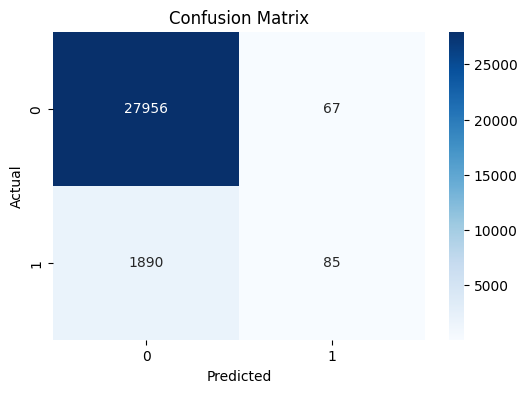

In [63]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

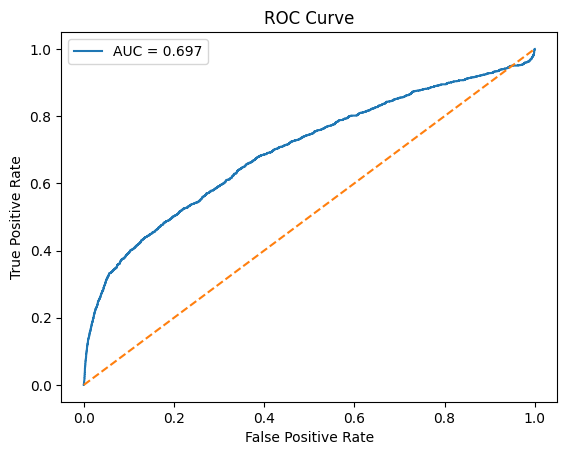

In [64]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure()
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc_score(y_test, y_prob))
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [65]:
# Trọng số của model
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_[0]
})

print(coefficients.sort_values(by="Coefficient", ascending=False))

                                Feature  Coefficient
2  NumberOfTime30-59DaysPastDueNotWorse     2.043716
6               NumberOfTimes90DaysLate     2.005440
9                    NumberOfDependents     0.111307
7          NumberRealEstateLoansOrLines     0.076784
0  RevolvingUtilizationOfUnsecuredLines    -0.017877
5       NumberOfOpenCreditLinesAndLoans    -0.035753
3                             DebtRatio    -0.048781
1                                   age    -0.425470
4                         MonthlyIncome    -0.492375
8  NumberOfTime60-89DaysPastDueNotWorse    -3.891347


In [66]:
model = LogisticRegression(
    C=1.0,
    penalty='l2',
    solver='liblinear'
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'liblinear'
,max_iter,100
,multi_class,'deprecated'


In [69]:
import joblib

joblib.dump(model, "F:/MachineLearning Tutorial/notebooks/model save/logistic_model.pkl")
joblib.dump(scaler, "F:/MachineLearning Tutorial/notebooks/model save/scaler.pkl")

['F:/MachineLearning Tutorial/notebooks/model save/scaler.pkl']

In [70]:
model = joblib.load("F:/MachineLearning Tutorial/notebooks/model save/logistic_model.pkl")
scaler = joblib.load("F:/MachineLearning Tutorial/notebooks/model save/scaler.pkl")